# Data Preprocessing & Feature Engineering
## Goal: Transform raw sensor data into ML-ready features

In [2]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from preprocess import load_data, add_rul, create_failure_label, drop_useless_sensors, scale_features
from features import add_rolling_features, add_lag_features, add_cycle_features, get_feature_columns

df = load_data('../data/raw/train_FD001.txt')
print("Raw data shape:", df.shape)
df.head(3)

✅ Data loaded: 22025 rows, 26 columns
Raw data shape: (22025, 26)


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42,0.00,100,518.941872,641.444094,1586.525628,1410.787657,14.618108,...,521.098153,2390.956502,8145.792781,8.395411,0.030060,390.886383,2387.918066,99.985237,39.303349,23.401523
1,1,2,100,0.84,100,518.847776,641.593925,1595.976409,1390.025132,14.642388,...,521.526430,2386.654585,8131.308716,8.416072,0.029954,391.057138,2387.911857,100.012009,39.151585,23.390774
2,1,3,42,0.00,100,518.801743,643.820343,1591.739592,1400.667713,14.589801,...,520.144845,2389.956407,8141.686456,8.426389,0.030017,391.366857,2388.120561,99.998318,39.250811,23.387330


✅ RUL column added. Max RUL: 296, Min RUL: 0
RUL distribution:
count    22025.0
mean       113.1
std         69.2
min          0.0
25%         55.0
50%        110.0
75%        165.0
max        296.0
Name: RUL, dtype: float64


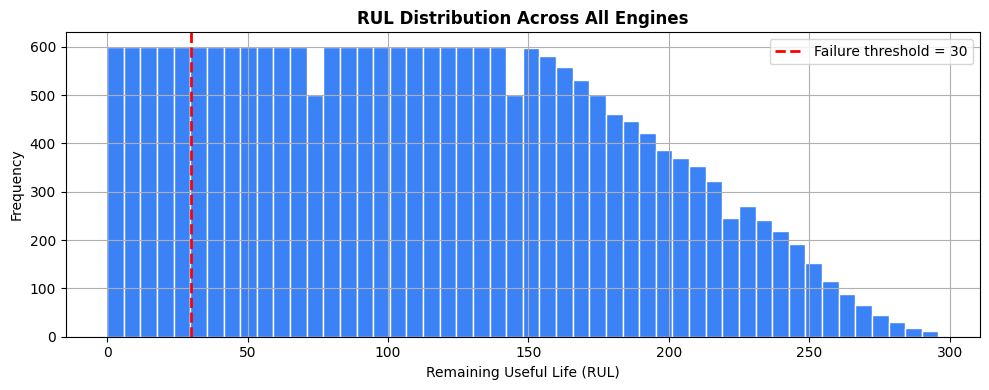

In [3]:
# ── Step 1: Add RUL ──
df = add_rul(df)
print("RUL distribution:")
print(df['RUL'].describe().round(1))

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
df['RUL'].hist(bins=50, ax=ax, color='#3b82f6', edgecolor='white')
ax.axvline(30, color='red', linestyle='--', linewidth=2, label='Failure threshold = 30')
ax.set_xlabel('Remaining Useful Life (RUL)')
ax.set_ylabel('Frequency')
ax.set_title('RUL Distribution Across All Engines', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/rul_distribution.png', dpi=150)
plt.show()

✅ Labels created | Failure: 3100 (14.1%) | Normal: 18925

Class balance:
failure_label
0    18925
1     3100
Name: count, dtype: int64

Imbalance ratio: 6.1:1


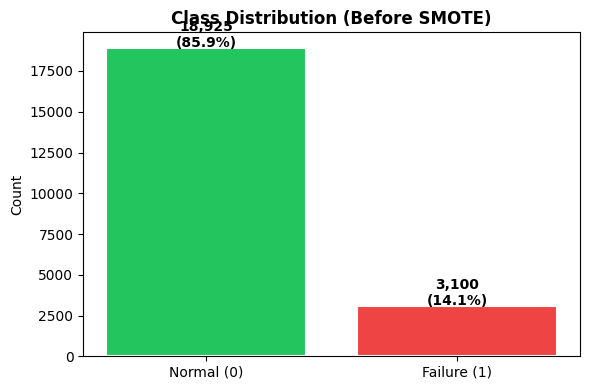

In [4]:
# ── Step 2: Create labels ──
df = create_failure_label(df, threshold=30)

print("\nClass balance:")
print(df['failure_label'].value_counts())
print(f"\nImbalance ratio: {df['failure_label'].value_counts()[0] / df['failure_label'].value_counts()[1]:.1f}:1")

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['failure_label'].value_counts()
bars = ax.bar(['Normal (0)', 'Failure (1)'], counts.values, 
               color=['#22c55e', '#ef4444'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Class Distribution (Before SMOTE)', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150)
plt.show()

In [5]:
# ── Step 3: Drop useless sensors ──
df_before = df.shape[1]
df = drop_useless_sensors(df)
print(f"Columns before: {df_before} → after: {df.shape[1]}")

sensor_cols = [c for c in df.columns if c.startswith('sensor_')]
print(f"Remaining sensors: {sensor_cols}")

✅ Dropped low-variance sensors. Remaining columns: 21
Columns before: 28 → after: 21
Remaining sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [6]:
# ── Step 4: Feature Engineering ──
df = add_rolling_features(df, sensor_cols, window=5)
df = add_lag_features(df, sensor_cols, lag=3)
df = add_cycle_features(df)

feature_cols = get_feature_columns(df)
print(f"\nTotal features created: {len(feature_cols)}")
print("\nSample features:")
print(feature_cols[:10])

✅ Rolling features added (window=5) for 14 sensors
✅ Lag features added (lag=3) for 14 sensors
✅ Cycle features added
✅ Total features for model: 60

Total features created: 60

Sample features:
['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11']


In [7]:
# ── Step 5: Scaling + save ──
df, scaler = scale_features(df, feature_cols)
df.to_csv('../data/processed/processed_data.csv', index=False)

print("\n✅ Processed data saved!")
print(f"Final shape: {df.shape}")
print("\nSample processed data:")
df[feature_cols[:5] + ['RUL', 'failure_label']].head(8)

✅ Features scaled (MinMax normalization applied)

✅ Processed data saved!
Final shape: (22025, 64)

Sample processed data:


,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,RUL,failure_label
0,0.42,0.000000,0.0,0.121917,0.119703,251,0
1,1.00,1.000000,0.0,0.129004,0.314199,250,0
2,0.42,0.000000,0.0,0.234317,0.227006,249,0
3,1.00,1.000000,0.0,0.085015,0.240392,248,0
4,0.25,0.833333,0.0,0.204702,0.165774,247,0
5,0.00,0.000000,0.0,0.164373,0.204215,246,0
6,1.00,0.833333,0.0,0.271533,0.147200,245,0
7,0.00,0.000000,0.0,0.232200,0.157268,244,0


✅ Data loaded: 22025 rows, 26 columns
✅ RUL column added. Max RUL: 296, Min RUL: 0


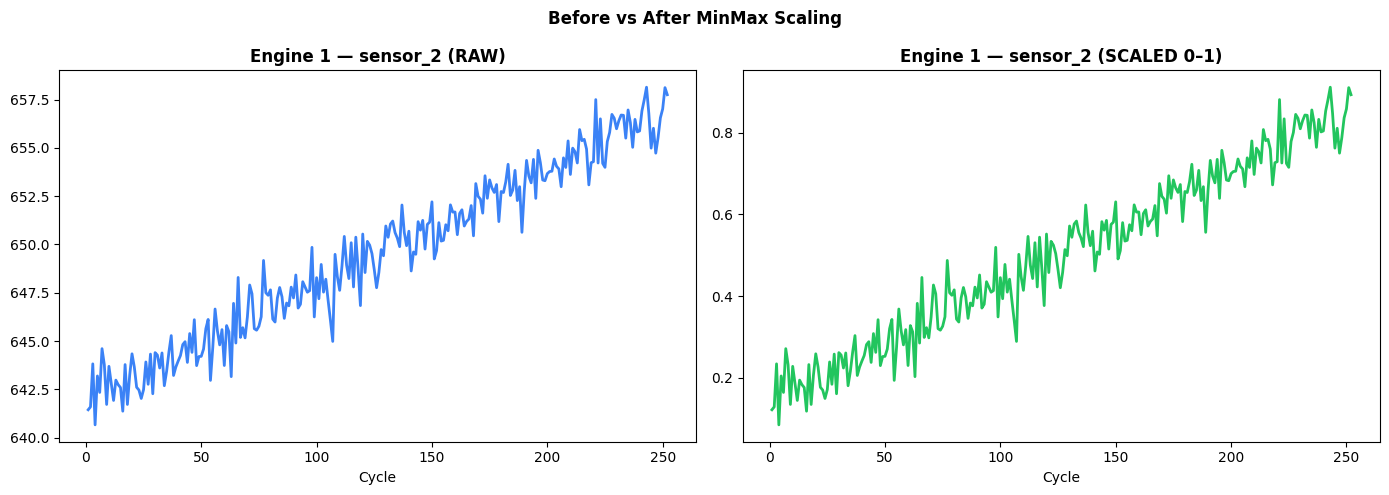

✅ Preprocessing verified!


In [8]:
# ── Verify: Compare raw vs processed sensor for one engine ──
raw = load_data('../data/raw/train_FD001.txt')
raw = add_rul(raw)
eng1_raw = raw[raw['unit_id'] == 1].sort_values('cycle')
eng1_proc = df[df['unit_id'] == 1].sort_values('cycle')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(eng1_raw['cycle'], eng1_raw['sensor_2'], color='#3b82f6', linewidth=2)
axes[0].set_title('Engine 1 — sensor_2 (RAW)', fontweight='bold')
axes[0].set_xlabel('Cycle')

axes[1].plot(eng1_proc['cycle'], eng1_proc['sensor_2'], color='#22c55e', linewidth=2)
axes[1].set_title('Engine 1 — sensor_2 (SCALED 0–1)', fontweight='bold')
axes[1].set_xlabel('Cycle')

plt.suptitle('Before vs After MinMax Scaling', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/scaling_comparison.png', dpi=150)
plt.show()
print("✅ Preprocessing verified!")